In [2]:
from pynq import Overlay
from pynq import allocate
from math import log
import numpy as np
import matplotlib.pyplot as plt
import random
import wave

In [3]:
ol = Overlay('fft_block_design_wrapper.xsa')

In [4]:
ol?

In [5]:
data_dma = ol.fft_block.data_dma
config_dma = ol.fft_block.data_dma

In [6]:
data_send = data_dma.sendchannel
data_recv = data_dma.recvchannel
conf_send = config_dma.sendchannel

In [7]:
def dataConv(fft_direction,size):
    fft_direction.zfill(8) #fills emply spots w/ 0s
    
    byte2 = '0'*8 #all of byte 2 is zeros
    
    x = int(log(size,2))
    fft_size = bin(x)[2:]
    
    fft_size.zfill(8)
    totalData = fft_direction+byte2+fft_size
    return int(totalData,2)

In [8]:
Nsamples = 8192

In [9]:
#wav files are 16 bit real
#allocate for input buffer expects np.csingle which is 64 bit complex (32 real 32 imag)

def wav_to_complex(filename, Nsamples, start_sec=0):
    wav = wave.open(filename, 'rb')

    fs = wav.getframerate()
    wav.setpos(fs * start_sec)  # skip silence at start
    fulldata=[]
    for i in range((wav.getnframes()//Nsamples)):
               
        frames = wav.readframes(Nsamples)
        audio = np.frombuffer(frames, dtype=np.int16).copy()

        if wav.getnchannels() == 2:
            audio = audio[::2]

        audio_f32 = audio.astype(np.float32) / 32768.0
        complex_data = audio_f32.astype(np.csingle)
        fulldata.append(complex_data)           
    return fulldata

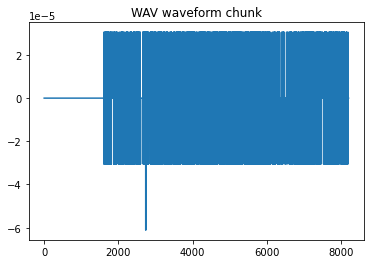

In [10]:
#FOR RANDOM GENERATED DATA

#data,t = genData(Nsamples,interval)
#plt.plot(t,np.real(data))

#FOR WAV DATA

data = wav_to_complex("Communication Breakdown (Remaster).wav", Nsamples)

plt.plot(np.real(data[0]))
plt.title("WAV waveform chunk")
plt.show()

In [11]:
#freq = np.fft.fftfreq(Nsamples*interval,1/Nsamples)

freq = np.fft.fftfreq(Nsamples, 1/44100) #for wav file

In [12]:
#ALLOCATING BUFFER SIZE FOR DMA
#using csingle as fft block expects 64 bit complex values

input_buffer = allocate(Nsamples, np.csingle)
output_buffer = allocate(Nsamples, np.csingle)
all_output = []
for part in data:
    np.copyto(input_buffer, part)
    data_send.transfer(input_buffer)
    data_recv.transfer(output_buffer)
    data_send.wait()
    data_recv.wait()
    all_output.append(np.abs(output_buffer.copy()))
    
all_output = np.concatenate(all_output)
freq = np.fft.fftfreq(Nsamples, 1/44100)
full_freq = np.tile(freq, len(data)) 



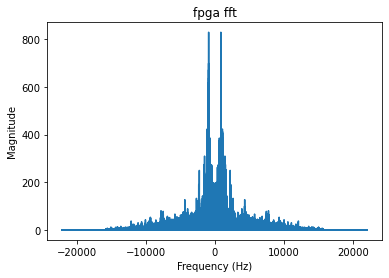

In [13]:
plt.plot(full_freq[:500000], all_output[:500000])
plt.title("fpga fft")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [14]:
combined = np.concatenate(data)[:500000]
npout = np.fft.fft(combined)
npfreq = np.fft.fftfreq(500000, 1/44100)

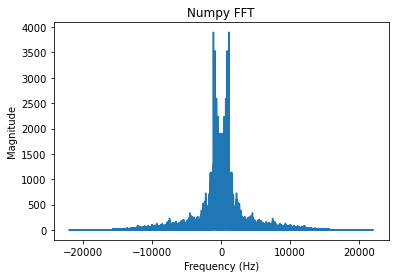

In [15]:
plt.plot(npfreq, np.abs(npout))
plt.title("Numpy FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [41]:
print("Gain values enter them in a range of -12dB to 12dB")
sub=float(input("Enter Sub-bass (0-60 Hz) Gains: "))
Bass=float(input("Enter Bass (60-250 Hz) Gain: "))
lomid=float(input("Enter Low-Mids (250-500 Hz) Gain: "))
mids=float(input("Enter Mid-range (500-2000 Hz) Gain: "))
himid=float(input("Enter High-Mids (2000-6000 Hz) Gain: "))
high=float(input("enter treble (6000-20000 Hz) Gain: "))

Gain values enter them in a range of -12dB to 12dB
Enter Sub-bass (0-60 Hz) Gains: 12
Enter Bass (60-250 Hz) Gain: 12
Enter Low-Mids (250-500 Hz) Gain: 12
Enter Mid-range (500-2000 Hz) Gain: 12
Enter High-Mids (2000-6000 Hz) Gain: 12
enter treble (6000-20000 Hz) Gain: -12


In [43]:
magnitudedb = 20 * np.log10(all_output)

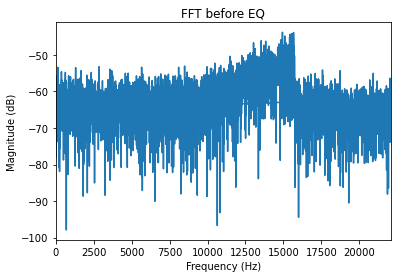

In [44]:
plt.plot(freq, magnitudedb[:8192])
plt.title("FFT before EQ")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 22050)
plt.show()

In [45]:
subrange= np.where((full_freq >= 0) & (full_freq < 60))
Bassrange=np.where((full_freq >= 60) & (full_freq < 250))
lomidrange=np.where((full_freq >= 250) & (full_freq < 500))
midsrange=np.where((full_freq >= 500) & (full_freq < 2000))
himidrange=np.where((full_freq >= 2000) & (full_freq < 6000))
highrange=np.where((full_freq >= 6000) & (full_freq <= 20000))

In [46]:
magnitudedb[subrange] += sub
magnitudedb[Bassrange] += Bass
magnitudedb[lomidrange] += lomid
magnitudedb[midsrange] += mids
magnitudedb[himidrange] += himid
magnitudedb[highrange] += high

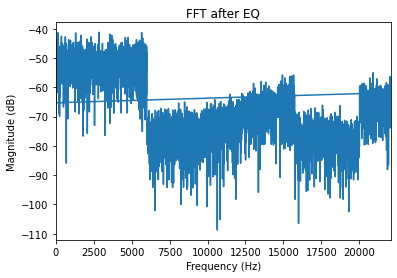

In [47]:
plt.plot(freq, magnitudedb[:8192])
plt.title("FFT after EQ")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 22050)
plt.show()